### [Feature Engineering Techniques for Numerical Variables](https://medium.com/@francescofranco_39234/3e172f90aeb0)

Feature engineering is an essential step in a machine learning pipeline, where raw data is transformed into more meaningful features that help the model better understand the relationships between the data.

Feature engineering often means applying transformations to the available data to overwrite or create new ones that, in the context of machine learning and data science, are used to train a model that can perform better precisely because of these transformations.

> Feature optimization is a key element in improving the quality of machine learning models, especially in the analysis of complex datasets.

In [1]:
import os, sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_wine, fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, QuantileTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

np.random.seed(42)
np.set_printoptions(suppress=True, precision=6)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.6f}'.format)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 10)

if "google.colab" not in str(get_ipython()):
  import matplotlib
  matplotlib.use('Agg')

import warnings
warnings.filterwarnings('ignore')

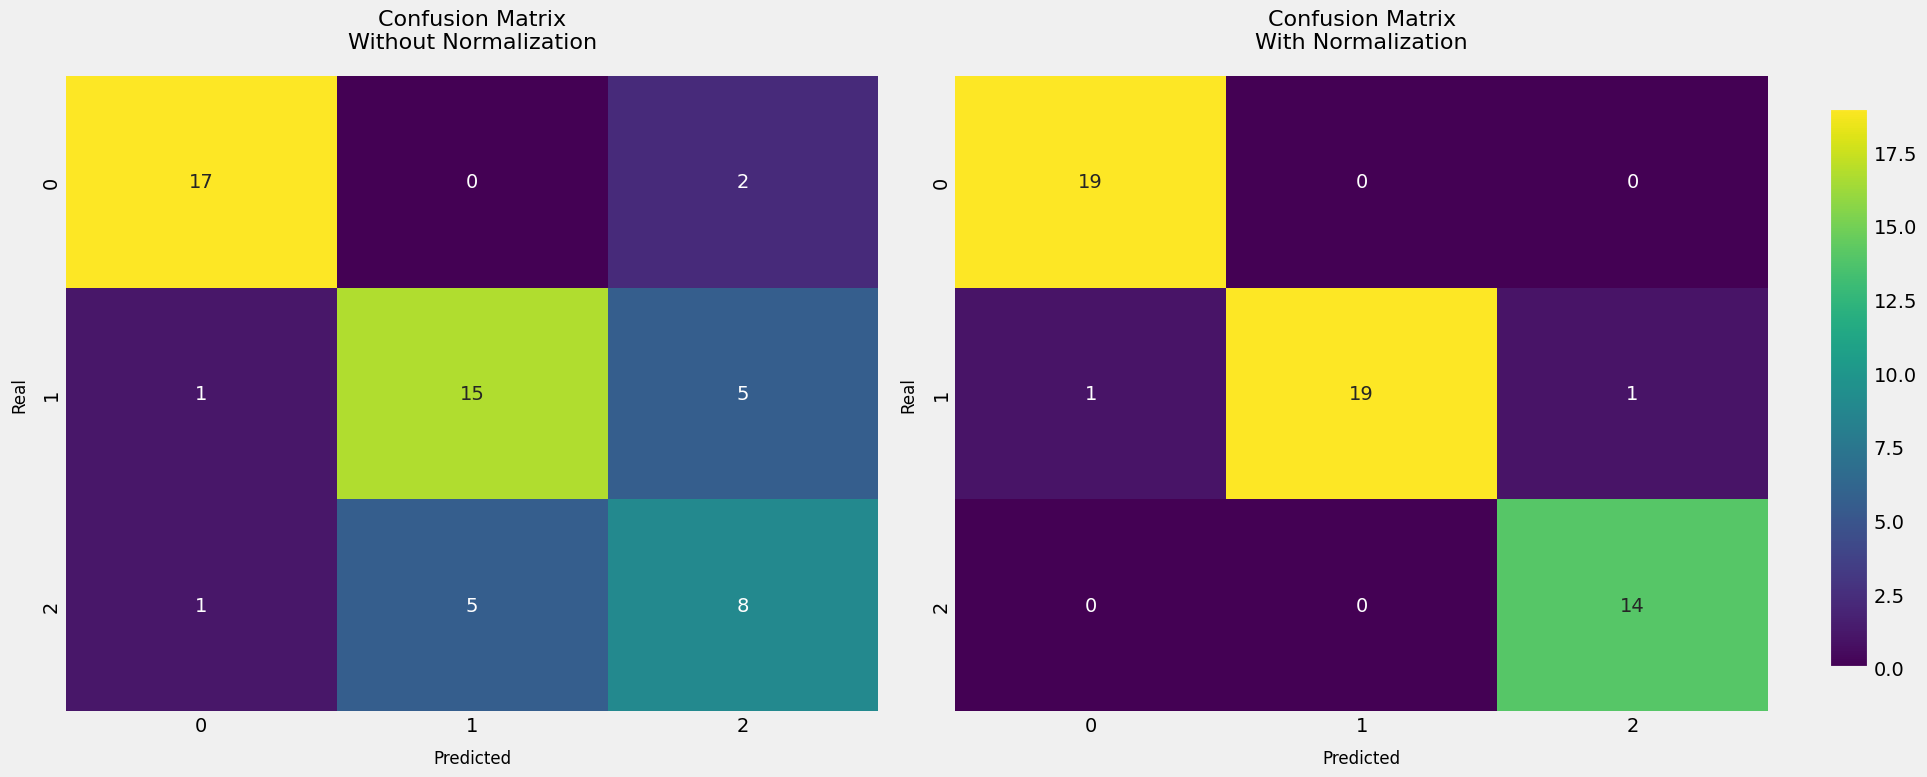

In [2]:
X, y = load_wine(return_X_y=True)

# Divide the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Function for training the model and obtaining the confusion matrix
def get_confusion_matrix(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return confusion_matrix(y_test, y_pred)

# Obtain the confusion matrix without normalization
cm_without_norm = get_confusion_matrix(X_train, X_test, y_train, y_test)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Obtain the confusion matrix with normalization
cm_with_norm = get_confusion_matrix(X_train_scaled, X_test_scaled, y_train, y_test)

# Create the figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Function for creating the heatmap
def plot_heatmap(ax, cm, title):
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=ax, cbar=False)
    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel('Predicted', fontsize=12, labelpad=10)
    ax.set_ylabel('Real', fontsize=12, labelpad=10)

# Plot the heatmap
plot_heatmap(ax1, cm_without_norm, 'Confusion Matrix\nWithout Normalization')
plot_heatmap(ax2, cm_with_norm, 'Confusion Matrix\nWith Normalization')

# Add a common colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=np.max([cm_without_norm, cm_with_norm])))
fig.colorbar(sm, cax=cbar_ax)

# Fix the layout and display the graphic
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [3]:
X = np.array([[1, 2], [3, 4]])
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

display(X_poly)
display(poly.get_feature_names_out(['x1', 'x2']))

array([[ 1.,  2.,  1.,  2.,  4.],
       [ 3.,  4.,  9., 12., 16.]])

array(['x1', 'x2', 'x1^2', 'x1 x2', 'x2^2'], dtype=object)

```python
fig, ax = plt.subplots(figsize=(12, 4))
average_week_demand = df.groupby(["weekday", "hour"])["count"].mean()
average_week_demand.plot(ax=ax)
_ = ax.set(
    title="Average hourly bike demand during the week",
    xticks=[i * 24 for i in range(7)],
    xticklabels=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    xlabel="Time of the week",
    ylabel="Number of bike rentals",
)
```

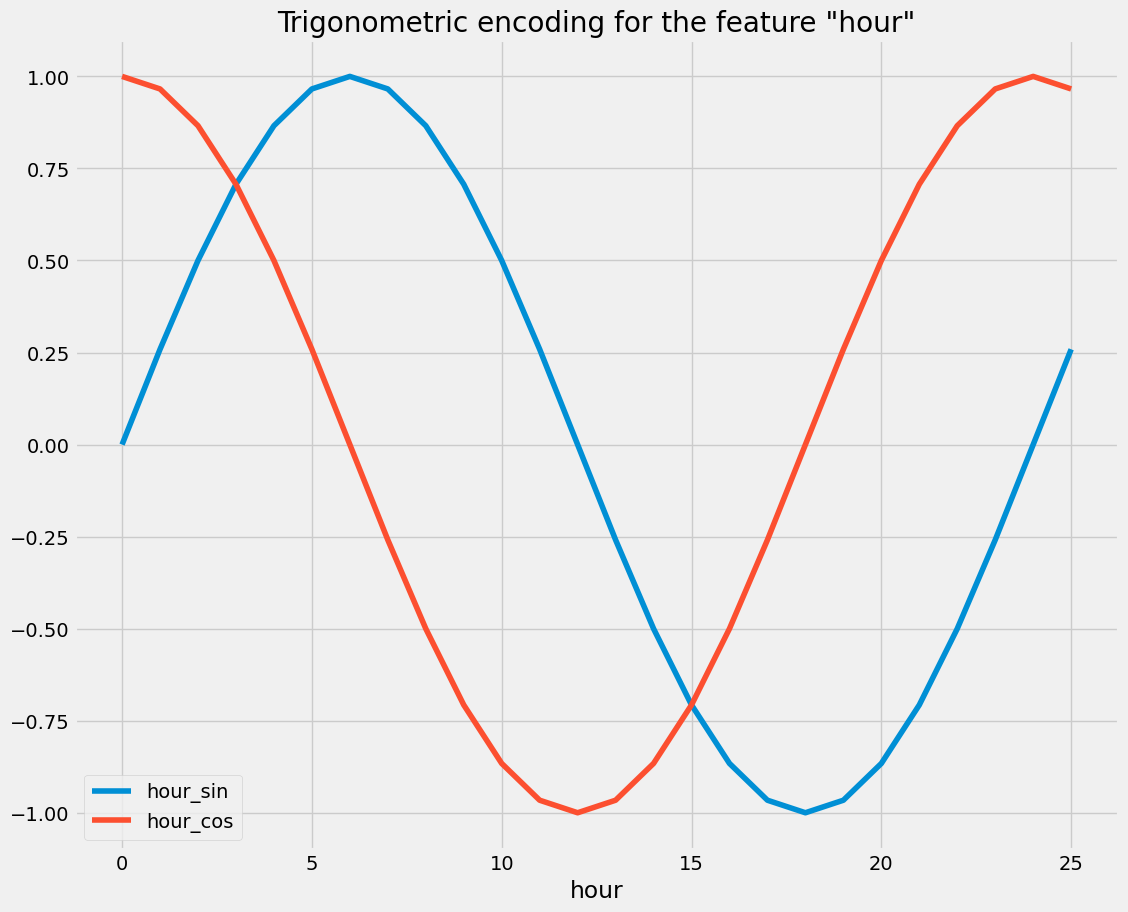

In [4]:
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

hour_df = pd.DataFrame(
    np.arange(26).reshape(-1, 1),
    columns=["hour"],
)
hour_df["hour_sin"] = sin_transformer(24).fit_transform(hour_df)["hour"]
hour_df["hour_cos"] = cos_transformer(24).fit_transform(hour_df)["hour"]
hour_df.plot(x="hour")
_ = plt.title('Trigonometric encoding for the feature "hour"')

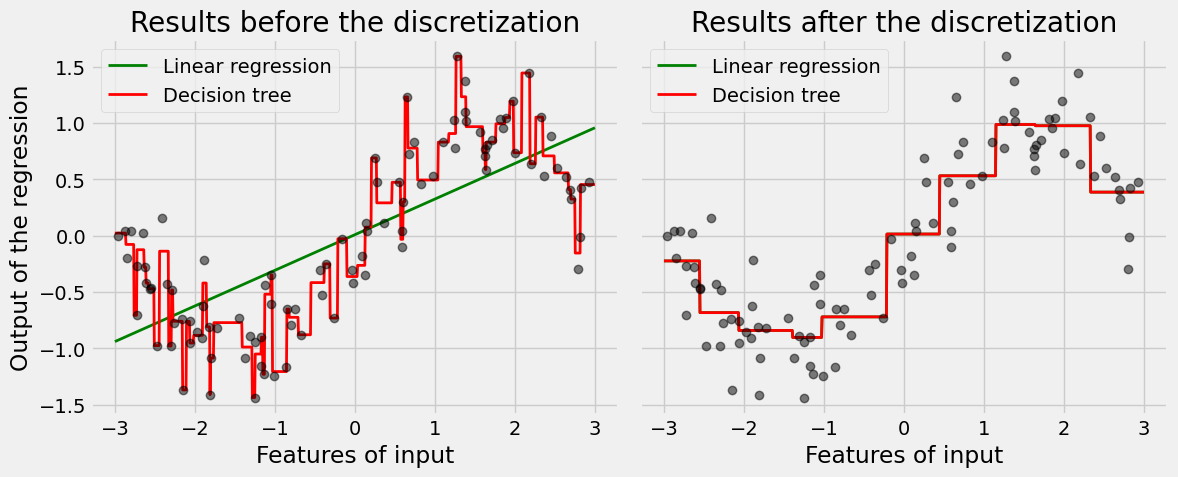

In [5]:
# Set the generator of  random numbers for reproducability
rnd = np.random.RandomState(42)

# Creation  of  dataset
X = rnd.uniform(-3, 3, size=100)  # 100 points betwen -3 and  3
y = np.sin(X) + rnd.normal(size=len(X)) / 3  # Sine wih noise added
X = X.reshape(-1, 1)  # Reshape to have correct form for sklearn

# Application of  KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=10, encode="onehot")
X_binned = discretizer.fit_transform(X)

# Preparation for  the visualization
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True, figsize=(12, 5))
line = np.linspace(-3, 3, 1000).reshape(-1, 1)  # Points for plotting

# Function for training and plotting the model
def train_and_plot(X_train, X_plot, ax, title):
    # Linear regression
    linear_reg = LinearRegression().fit(X_train, y)
    ax.plot(line, linear_reg.predict(X_plot), linewidth=2, color="green", label="Linear regression")

    # Decision tree
    tree_reg = DecisionTreeRegressor(min_samples_split=3, random_state=0).fit(X_train, y)
    ax.plot(line, tree_reg.predict(X_plot), linewidth=2, color="red", label="Decision tree")

    #  Original data
    ax.plot(X[:, 0], y, "o", c="k", alpha=0.5)
    ax.legend(loc="best")
    ax.set_xlabel("Features of input")
    ax.set_title(title)

# Plot for original data
train_and_plot(X, line, ax1, "Results before the discretization")
ax1.set_ylabel("Output of the regression")

# Plot for discretized data
line_binned = discretizer.transform(line)
train_and_plot(X_binned, line_binned, ax2, "Results after the discretization")

plt.tight_layout()
plt.show()

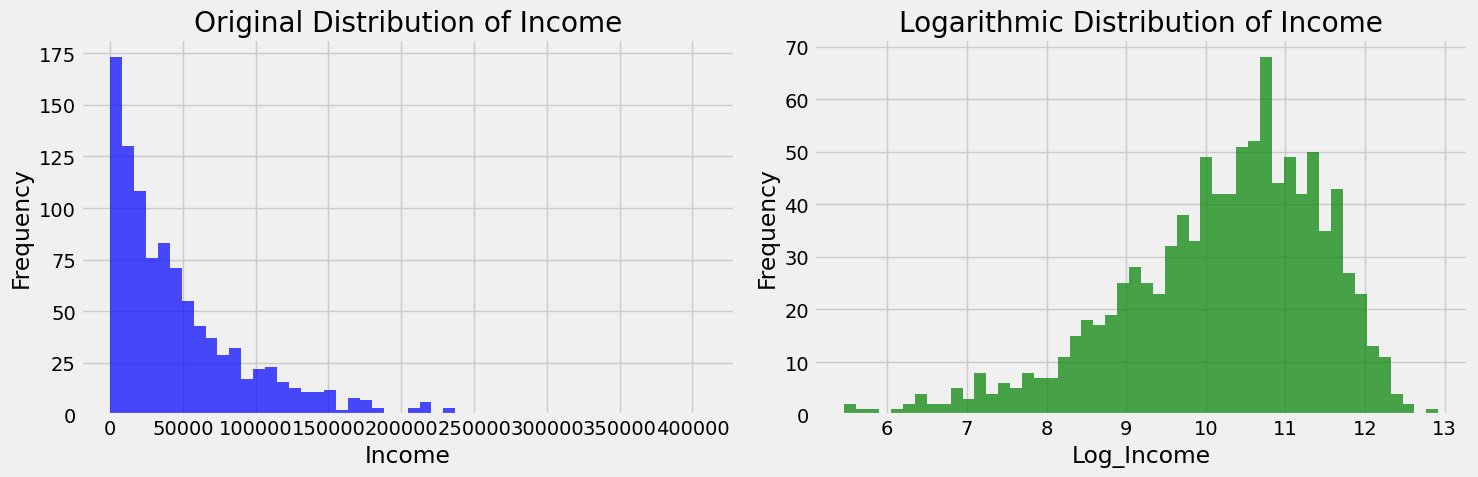

In [6]:
# Creating a dataset of examples with positively asimmetric numbers
np.random.seed(42)
data = {
    'Income': np.random.exponential(scale=50000, size=1000)  # exponential distibution to simulate the skewness
}
df = pd.DataFrame(data)

# Creation of a figure with two side-by-side subgraphs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot of the original distribution
axes[0].hist(df['Income'], bins=50, color='blue', alpha=0.7)
axes[0].set_title('Original Distribution of Income')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')

# Application of logarithmic transformation
df['Log_Income'] = np.log1p(df['Income'])  # log1p is equivalent to log(x + 1)

# Plot of the transformed distribution
axes[1].hist(df['Log_Income'], bins=50, color='green', alpha=0.7)
axes[1].set_title('Logarithmic Distribution of Income')
axes[1].set_xlabel('Log_Income')
axes[1].set_ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()

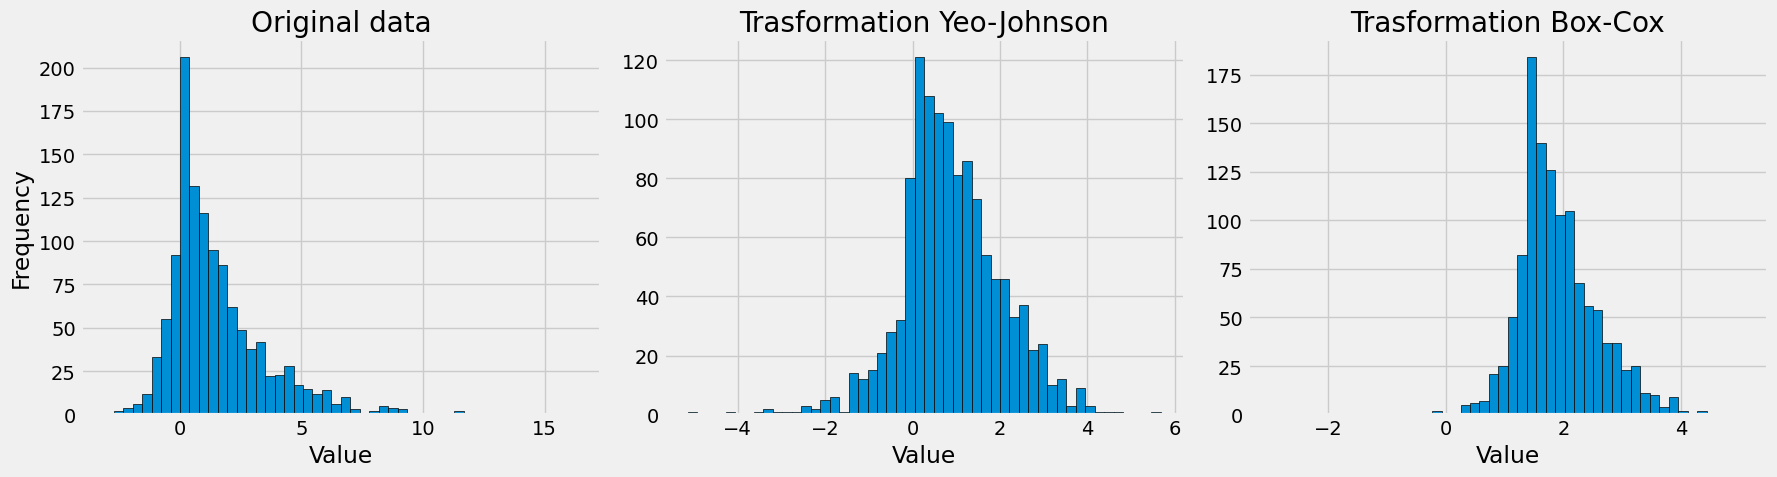

In [7]:
# Generate data with positive and negative values
np.random.seed(42)
data_positive = np.random.exponential(scale=2, size=1000)
data_negative = -np.random.exponential(scale=0.5, size=200)
data = np.concatenate([data_positive, data_negative])

# Create two instances of PowerTransformer, one for Yeo-Johnson and one for Box-Cox in order to confront them
pt_yj = PowerTransformer(method='yeo-johnson', standardize=False)
pt_bc = PowerTransformer(method='box-cox', standardize=False)

# Apply the transformations
data_yj = pt_yj.fit_transform(data.reshape(-1, 1))
# Box-Cox requires positive data, so we add an offset to render hem all positive
data_offset = data - np.min(data) + 1e-6
data_bc = pt_bc.fit_transform(data_offset.reshape(-1, 1))

# Visualize the results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.hist(data, bins=50, edgecolor='black')
ax1.set_title("Original data")
ax1.set_xlabel("Value")
ax1.set_ylabel("Frequency")

ax2.hist(data_yj, bins=50, edgecolor='black')
ax2.set_title("Trasformation Yeo-Johnson")
ax2.set_xlabel("Value")

ax3.hist(data_bc, bins=50, edgecolor='black')
ax3.set_title("Trasformation Box-Cox")
ax3.set_xlabel("Value")

plt.tight_layout()
plt.show()

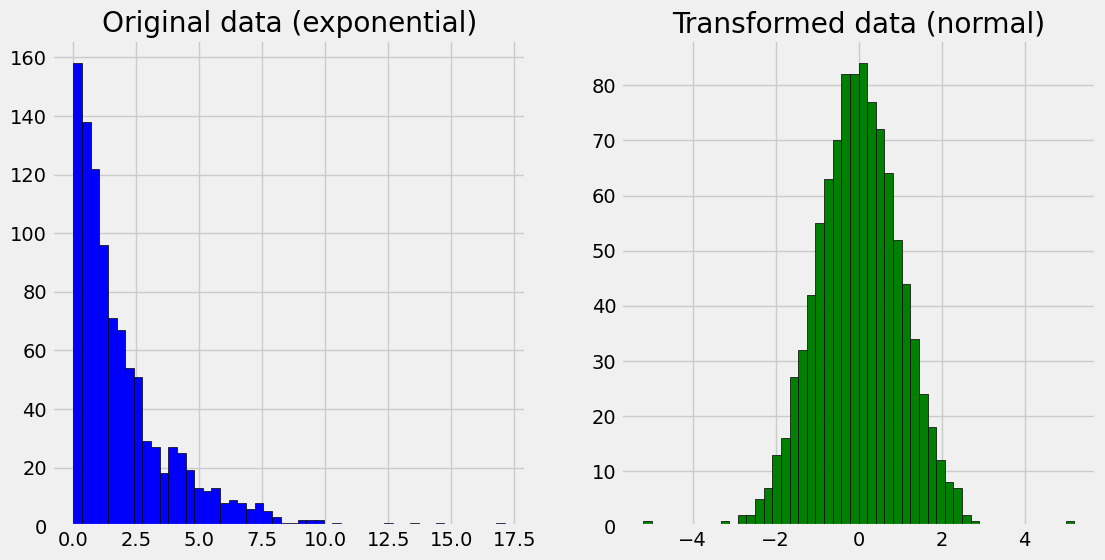

In [8]:
# Create a dataset of examples with a distorted distribution
np.random.seed(0)
data = np.random.exponential(scale=2, size=(1000, 1))  # Exponential distribution

# Initialize the QuantileTransformer
quantile_transformer = QuantileTransformer(n_quantiles=100, output_distribution='normal')

# Apply the transformation
data_transformed = quantile_transformer.fit_transform(data)

# Visualization of the original and transformed data
plt.figure(figsize=(12, 6))

# Histogram of the original data
plt.subplot(1, 2, 1)
plt.hist(data, bins=50, color='blue', edgecolor='black')
plt.title("Original data (exponential)")

# Histogram of the transformed data
plt.subplot(1, 2, 2)
plt.hist(data_transformed, bins=50, color='green', edgecolor='black')
plt.title("Transformed data (normal)")
plt.show()

✓ Loaded 1288 real face images
✓ Dataset shape: (1288, 1850)
✓ Image dimensions: 50x37 pixels
✓ SVD complete


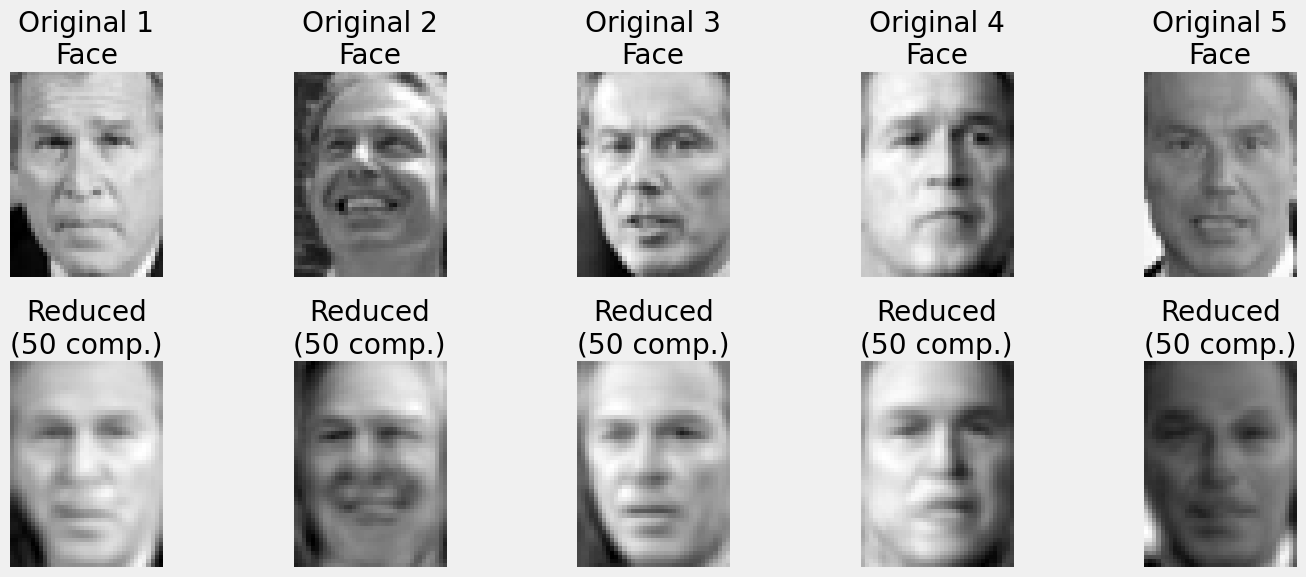


Mean Reconstruction Error (MSE): 0.0035
Cumulative variance with 50 components: 0.8431


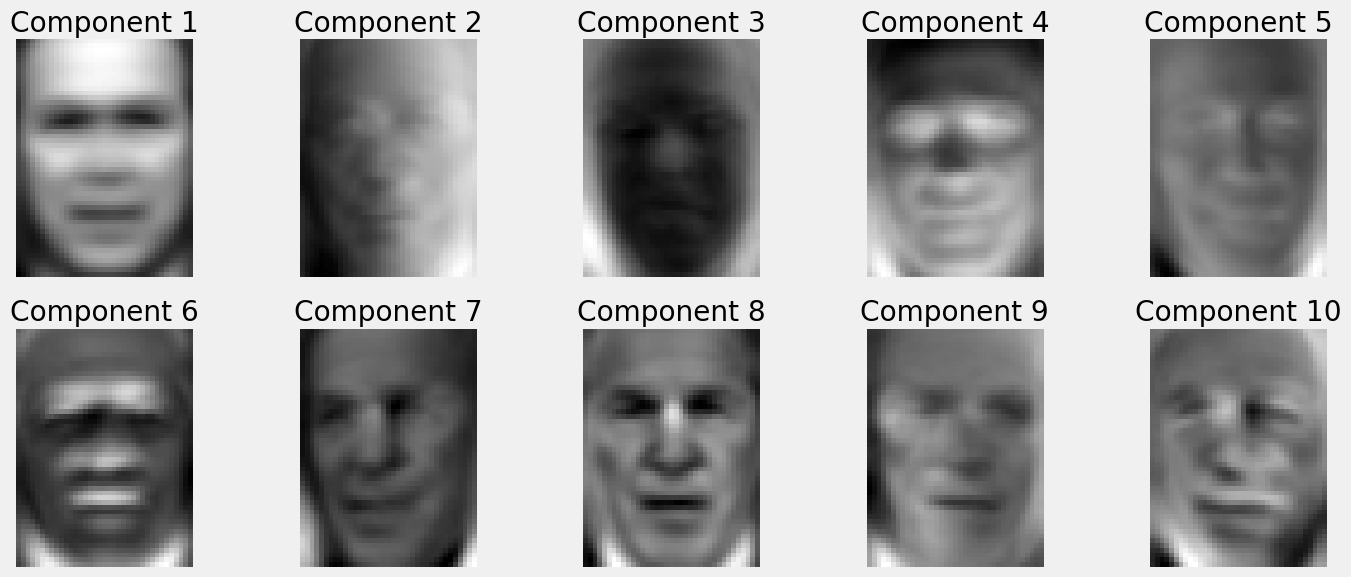

In [9]:
IN_COLAB = "google.colab" in str(get_ipython()) or "google.colab" in sys.modules
# Create output directory if it doesn't exist
if not IN_COLAB:
  output_dir = 'output_plots'
  os.makedirs(output_dir, exist_ok=True)
  print(f"Saving plots to: {output_dir}/")

# Load the dataset - Labeled Faces in the Wild
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
X = lfw_people.data
n_samples, h, w = lfw_people.images.shape
print(f"✓ Loaded {n_samples} real face images")
print(f"✓ Dataset shape: {X.shape}")
print(f"✓ Image dimensions: {h}x{w} pixels")

# Number of components to use for the reduction
n_components = 50

svd = TruncatedSVD(n_components=n_components, random_state=42)
X_transformed = svd.fit_transform(X)
print("✓ SVD complete")

# Function to reconstruct an image
def reconstruct_image(svd, X_transformed):
    return np.dot(X_transformed, svd.components_)

X_reconstructed = reconstruct_image(svd, X_transformed)

# Function to visualize the original faces and reduced
def plot_transposed_original_and_reduced(X_original, X_reduced, n_faces=5):
    fig, axes = plt.subplots(2, n_faces, figsize=(3*n_faces, 6))
    random_indices = np.random.choice(X_original.shape[0], n_faces, replace=False)

    for i, idx in enumerate(random_indices):
        # Original face
        axes[0, i].imshow(X_original[idx].reshape(h, w), cmap='gray')
        axes[0, i].set_title(f'Original {i+1}\nFace')
        axes[0, i].axis('off')

        # Reduced face
        axes[1, i].imshow(X_reduced[idx].reshape(h, w), cmap='gray')
        axes[1, i].set_title(f'Reduced\n({n_components} comp.)')
        axes[1, i].axis('off')

    plt.tight_layout()
    if not IN_COLAB:
      plot1_path = os.path.join(output_dir, 'original_vs_reduced_faces.png')
      plt.savefig(plot1_path, dpi=200, bbox_inches='tight')
      print(f"✓ Saved: {plot1_path}")
      plt.close()
    else:
      plt.show()

plot_transposed_original_and_reduced(X, X_reconstructed)

# Calculate and print mean reconstruction error
mse = np.mean((X - X_reconstructed) ** 2)
print(f"\nMean Reconstruction Error (MSE): {mse:.4f}")

# Print the cumulative variance
explained_variance_ratio = svd.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
print(f"Cumulative variance with {n_components} components: {cumulative_variance_ratio[-1]:.4f}")

# Visualize the primary components
n_components_show = min(10, n_components)
components = svd.components_[:n_components_show].reshape((n_components_show, h, w))
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < n_components_show:
        ax.imshow(components[i], cmap='gray')
        ax.set_title(f'Component {i+1}')
    ax.axis('off')
plt.tight_layout()
if not IN_COLAB:
  plot2_path = os.path.join(output_dir, 'principal_components.png')
  plt.savefig(plot2_path, dpi=150, bbox_inches='tight')
  plt.close()
  print(f"✓ Saved: {plot2_path}")
else:
  plt.show()